# **Jammy Flows installation**

In [ ]:
!pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-pb__eqov
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-pb__eqov
  Resolved https://github.com/thoglu/jammy_flows.git to commit 3ec7872f8535b8e8db2e31f74a7c55bad5c54d5f
  Preparing metadata (setup.py) ... done
  Created wheel for jammy_flows: filename=jammy_flows-1.0.0-py3-none-any.whl size=174322 sha256=9883fa9295a93be356afff4d9357aae807a4a755ce8d2d9524a4bb55fe8a3a62
  Stored in directory: /tmp/pip-ephem-wheel-cache-uxhmzsck/wheels/c0/ce/35/60016f460c07fecc64f55db2a40862c9add349fb0620845532
Successfully built jammy_flows


# **Import libraries**

In [ ]:
import os
import sys
import time
import copy
import glob
import subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from scipy.stats import norm
from google.colab import drive
import jammy_flows

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


# **DEVICE SETTING**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# **DATA LOADING**

In [ ]:
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/')
DATA_PATH = '/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DATA/GALAH/'

Mounted at /content/drive


# **HELPER FUNCTIONS**

In [ ]:
def normalize(labels, p):

    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

# Function to denormalize the labels back to their original scale
def denormalize(labels, ranges):

    return labels * (ranges[1] - ranges[0]) + ranges[0]

def denormalize_std(uncertainty, ranges):

    return uncertainty * (ranges[1] - ranges[0])


def get_normalized_data(data_path, return_SNR=False):

    # Load the spectra data
    spectra = np.load(f"{data_path}/spectra.npy")
    spectra_length = spectra.shape[1]

    # Load the labels data
    # labels: mass, age, l_bol, dist, t_eff, log_g, fe_h
    labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h"]
    labels = np.load(f"{data_path}/labels.npy")
    SNR = labels[:, -1]
    labels = labels[:, :-1]

    # We only use the labels: t_eff, log_g, fe_h
    labelNames = labelNames[-3:]
    labels = labels[:, -3:]
    n_labels = labels.shape[1]

    labels, ranges = normalize(labels, 0.05)

    # Normalize spectra
    spectra = np.log(np.maximum(spectra, 0.2))

    if return_SNR:
        return spectra, labels, spectra_length, n_labels, labelNames, ranges, SNR
    return spectra, labels, spectra_length, n_labels, labelNames, ranges

# **LOSS FUNCTION**

In [ ]:
def nf_loss(model, batch_spectra, batch_labels):
  log_pdfs = model.log_pdf_evaluation(batch_labels, batch_spectra) # get the probability of the labels given the input data
  loss = -log_pdfs.mean() # take the negative mean of the log probabilities
  return loss

# **TRAIN MODEL**

In [ ]:
def train_model_nf(model, train_loader, val_loader, learning_rate, num_epochs, patience,
                device, plot_fn=None, plot_interval=10, plot_kwargs=None, model_name=None):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(num_epochs):
        start_time = time.time()  # Start the timer for this epoch

        # Training phase
        model.train()
        total_train_loss = 0.0
        for step, (batch_spectra, batch_labels) in enumerate(train_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)  # Add channel dimension for CNNs

            optimizer.zero_grad()

            loss = nf_loss(model, batch_spectra, batch_labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            # Print progress every 10th step, updating the same line
            if (step + 1) % 10 == 0:
                sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
                sys.stdout.flush()

        sys.stdout.write("\n")  # Move to the next line after the epoch

        # Validation phase
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_spectra, batch_labels in val_loader:
                batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)

                val_loss = nf_loss(model, batch_spectra, batch_labels)

                total_val_loss += val_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Store losses for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Print epoch summary
        epoch_time = time.time() - start_time  # Calculate epoch time
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} seconds")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.copy(model.state_dict())
            # Save the best model to the "models" directory
            if not os.path.exists('models'):
                os.makedirs('models')
            if model_name is not None:
                torch.save(best_model, f"models/{model_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        if(epoch%plot_interval==0):
            if(plot_fn is not None):

                assert(plot_kwargs is not None)

                assert("test_loader" in plot_kwargs.keys())
                assert("ranges" in plot_kwargs.keys())
                assert("plot_folder" in plot_kwargs.keys())

                plot_fn(model,
                        plot_kwargs["test_loader"],
                        nf_loss,
                        device,
                        plot_kwargs["ranges"],
                        train_losses,
                        val_losses,
                        plot_folder=plot_kwargs["plot_folder"],
                        suffix="epoch_%.5d" % epoch)

    return train_losses, val_losses, best_model

# **EVALUATE MODEL**

In [ ]:
def evaluate_model(model, test_loader, device, samplesize=1000):

    print("Evaluating Normalizing Flow model on the test dataset...")
    model.eval()
    total_test_nll = 0.0

    all_predictions = []
    all_uncertainties = []
    all_true_labels = []

    first_batch_spectra=None
    first_batch_labels=None

    with torch.no_grad():
        for batch_index, (batch_spectra, batch_labels) in enumerate(test_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)

            # Apply loss function
            total_test_nll += nf_loss(model, batch_spectra, batch_labels).item()

            outputs = model(batch_spectra, samplesize_per_batchitem=samplesize)

            n = batch_labels.shape[1]
            means = outputs[:, :n]
            stds = outputs[:, n:]

            all_predictions.append(means.cpu())
            all_uncertainties.append(stds.cpu())
            all_true_labels.append(batch_labels.cpu())

            if(batch_index==0):
                first_batch_spectra=batch_spectra
                first_batch_labels=batch_labels

    avg_test_loss = total_test_nll / len(test_loader)
    print(f"Final Test Loss: {avg_test_loss:.4f}")
    return torch.cat(all_predictions).numpy(), torch.cat(all_uncertainties).numpy(), torch.cat(all_true_labels).numpy(), first_batch_spectra, first_batch_labels

# **MODELS**

In [ ]:
class TinyCNNEncoder(nn.Module):
	def __init__(self, num_flow_parameters):
		super(TinyCNNEncoder, self).__init__()

		self.model = nn.Sequential(
			nn.Conv1d(1, 10, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(10, 20, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(20),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(20, 40, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(40),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(40, 10, kernel_size=1),
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(2),

			nn.Conv1d(10, 12, kernel_size=3),
			nn.ReLU(),
			nn.BatchNorm1d(12),
			nn.Dropout(0.2),

			nn.Conv1d(12, 10, kernel_size=1),
			nn.Dropout(0.2),

			nn.Linear(300, 32),
			nn.ReLU(),
			nn.Flatten(),
			nn.Linear(10*32, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, num_flow_parameters)

		)

	def forward(self, x):
		# x = torch.unsqueeze(x,1)
		x = self.model(x)
		return x

In [ ]:
fp64_on_cpu = False

In [ ]:
class NormFlow(nn.Module):

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        super().__init__()
        # we define a 3-d PDF over Euclidean spae (e3)
        # using recommended settings (https://github.com/thoglu/jammy_flows/issues/5 scroll down)
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
                opt_dict["t"]["cov_type"] = "diagonal"
                flow_defs = "t"
        elif (nf_type == "full_gaussian"):
                opt_dict["t"]["cov_type"] = "full"
                flow_defs = "t"
        elif (nf_type == "full_flow"):
                opt_dict["t"]["cov_type"] = "full"
                flow_defs = "gggt"
        else:
                raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        # 3d PDF (e3) with ggggt flow structure. Four Gaussianation-flow (https://arxiv.org/abs/2003.01941) layers ("g") and an affine flow ("t")
        self.pdf = jammy_flows.pdf("e3", flow_defs, options_overwrite=opt_dict,
                                amortize_everything=True, amortization_mlp_use_custom_mode=True)

        # get the number of flow parameters
        num_flow_parameters = self.pdf.total_number_amortizable_params

        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        # latent dimension (output of the CNN encoder) is set to 128
        self.encoder = encoder(num_flow_parameters)

    def log_pdf_evaluation(self, target_labels, input_data):

        latent_intermediate = self.encoder(input_data)  # get the flow parameters from the CNN encoder

        if (self.nf_type == "full_flow"):
                # convert to double. Double precision is needed for the Gaussianization flow. This is for numerical stability.
                if fp64_on_cpu:  # MPS does not support double precision, therefore we need to run the flow on the CPU
                        latent_intermediate = latent_intermediate.cpu().to(torch.float64)
                        target_labels = target_labels.cpu().to(torch.float64)
                else:
                        latent_intermediate = latent_intermediate.to(torch.float64)
                        target_labels = target_labels.to(torch.float64)

        # evaluate the log PDF at the target labels
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):

        # for full flow we need to convert to double precision for the normalizing flow
        # for numerical stability
        if (self.nf_type == "full_flow"):
                # convert to double
                if fp64_on_cpu: # MPS does not support double precision, therefore we need to run the flow on the CPU
                        flow_params = flow_params.cpu().to(torch.float64)
                else:
                        flow_params = flow_params.to(torch.float64)

        batch_size = flow_params.shape[0] # get the batch size
        # sample from the normalizing flow
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
                samplesize_per_batchitem, dim=0), allow_gradients=False)

        # reshape the samples to be grouped by batch item
        reshaped_samples = repeated_samples[:, None, :].view(
                batch_size, samplesize_per_batchitem, -1)

        return reshaped_samples

    def forward(self, input_data, samplesize_per_batchitem=1000):

        flow_params=self.encoder(input_data)
        samples=self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        # form mean along dim 1 (samples)
        means=samples.mean(dim=1)
        # form std along dim 1 (samples)
        std_deviations=samples.std(dim=1)

        # return means and std deviations as a concatenated tensor along dim 1
        return torch.cat([means, std_deviations], dim=1)

    def visualize_pdf(self, input_data, filename=None, samplesize=1000, batch_index=0, truth=None):

        # pick out one input from batch
        input_bitem = input_data[batch_index:batch_index+1]

        # get the flow parameters (by passing the input data through the CNN encoder network)
        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow (i.e. samples are drawn from the base distribution and transformed by the flow
        # using the change-of-variable formula)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)
        # the rest of the code is just plotting.

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        # so we calculate the mean and std of the samples
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        labels = ["T_eff", "log g", "[Fe/H]"]
        fig, axdict = plt.subplots(3, 1)

        for dim_ind in range(3):

            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                                bins=50, alpha=0.5, label="Density based on Flow samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green", lw = 2,
                                                label="Gaussian approximation")

            # plot the true value if it is given
            if (truth is not None):
                    true_value = truth[dim_ind].cpu().item()
                    axdict[dim_ind].axvline(
                            true_value, color="red", linestyle="--",
                                  lw=2, label=f"True value")

            axdict[dim_ind].set_ylabel("Density")
            axdict[dim_ind].set_xlabel(labels[dim_ind])

            # plot the legend only for the first panel
            if (dim_ind == 0):
                    axdict[dim_ind].legend()

        plt.tight_layout()
        if (filename is not None):
            plt.savefig(filename)
            print(f"Plot saved as: {filename}")

        plt.show()


# **PLOTTING FUNCTIONS**

In [ ]:
def plot_loss(train_losses, val_losses):
  plt.figure(figsize=(10, 6))
  plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color = 'royalblue')
  plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color = 'orange')
  plt.xlabel('Epoch')
  plt.ylabel('Loss (NLL)')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
def plot_scatter(all_predictions, all_true_labels, label_names):
  plt.figure(figsize=(16,7.5))
  colors = ['royalblue', 'forestgreen', 'darkviolet']
  for j, c in zip(range(n_labels), colors):
      plt.subplot(1,3,j+1)
      gt = all_true_labels
      plt.scatter(gt[:,j],y=all_predictions[:,j],s=10,alpha=0.4, color=c)
      plt.plot([gt[:,j].min().item(),gt[:,j].max().item()],[gt[:,j].min().item(),gt[:,j].max().item()],c="black",linestyle="dashed",label="Perfect prediction")
      plt.xlabel("True "+labelNames[j])
      plt.ylabel("Predicted "+labelNames[j])
      plt.legend()
  plt.tight_layout()
  plt.show()

In [ ]:
import scipy.stats as stats
def plot_pulls(all_predictions, all_true_labels, all_uncertainties, label_names):

  pulls = (all_predictions - all_true_labels) / all_uncertainties

  plt.figure(figsize=(18, 5))

  colors = ['royalblue', 'forestgreen', 'darkviolet']
  for i, c in zip(range(n_labels), colors):
      plt.subplot(1, 3, i + 1)

      # Plot histogram of pulls
      data = pulls[:, i]
      mu_pull, std_pull = np.mean(data), np.std(data)

      plt.hist(data, bins=30, density=True, alpha=0.6, color=c, label='Pulls')

      # Overplot the Standard Normal Distribution (Goal)
      x = np.linspace(-4, 4, 100)
      plt.plot(x, stats.norm.pdf(x, 0, 1), '--', lw=2, label='Normal(0,1)', color='gold')

      # Overplot the actual fit of the pulls
      plt.plot(x, stats.norm.pdf(x, mu_pull, std_pull), 'black', lw=2, label=f'Fit: μ={mu_pull:.2f}, σ={std_pull:.2f}')

      plt.title(f"Pull Distribution: {labelNames[i]}")
      plt.xlabel(r"($\mu_i - y_i$) / $\sigma_i$")
      plt.ylabel("Density")
      plt.xlim(-5, 5)
      plt.legend()

  plt.tight_layout()
  plt.show()

In [ ]:
def plot_residuals(pred_mean, all_true_labels, label_names):

    plt.figure(figsize=(16, 7.5))
    n_labels = len(label_names)

    colors = ['royalblue', 'forestgreen', 'darkviolet']

    # Residual
    diff = all_true_labels - pred_mean

    for j,c in zip(range(n_labels), colors):
        plt.subplot(1, 3, j + 1)

        # Histogram
        plt.hist(diff[:, j], bins=50, alpha=0.7, color=c, edgecolor=c, density=True)

        mu = diff[:, j].mean()
        std = diff[:, j].std()

        plt.axvline(mu, color="red", linestyle="dashed", linewidth=1.5, label=f'Mean: {mu:.2f}')
        plt.axvline(mu - std, color="black", linestyle="dotted", linewidth=1.5, label=f'Std: {std:.2f}')
        plt.axvline(mu + std, color="black", linestyle="dotted", linewidth=1.5)

        plt.xlabel(f"True - Predicted [{label_names[j]}]")
        plt.ylabel("Density")
        plt.title(f"Residuals: {label_names[j]}")
        plt.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

In [ ]:
def uncertainty_distribution(all_uncertainties, labelNames):
  plt.figure(figsize=(16, 6))
  colors = ['royalblue', 'forestgreen', 'darkviolet']
  for j,c in zip(range(n_labels), colors):
      plt.subplot(1, 3, j + 1)
      plt.hist(all_uncertainties[:, j], bins=50, color=c, edgecolor='black', alpha=0.6, label='Uncertainty Distribution')

      plt.xlabel(f'Predicted uncertainty [{labelNames[j]}]')
      plt.ylabel('Frequency')
      plt.grid(True)
      plt.legend()
  plt.tight_layout()
  plt.show()

# **HYPERPARAMETERS**

In [ ]:
# Hyperparameters
learning_rate = 1e-4
batch_size = 128
num_epochs = 100
patience = 30 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
train_fraction = 0.7 # Fraction of the data used for training
val_fraction = 0.15 # Fraction of the data used for validation

# **DIAGONAL GAUSSIAN**

In [ ]:
model_choice = 'diagonal_gaussian'

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH, return_SNR=False)

# Convert numpy arrays to PyTorch tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split the data into training, validation, and test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = NormFlow(encoder=TinyCNNEncoder, nf_type=model_choice).to(device)

if model_choice == "full_flow":
    model = model.to(torch.float64)

train_losses_diag, val_losses_diag, best_model_state_diag = train_model_nf(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    patience=patience,
    device=device,
    model_name=model_choice
)

model.load_state_dict(best_model_state_diag)

preds_norm_diag, stds_norm_diag, true_norm_diag, first_spec_diag, first_lab_diag = evaluate_model(
    model,
    test_loader,
    device,
    samplesize=1000
)

all_predictions_diag = denormalize(preds_norm_diag, ranges)
all_true_labels_diag = denormalize(true_norm_diag, ranges)
all_uncertainties_diag = denormalize_std(stds_norm_diag, ranges)

Using device: cuda
The normalizing flow has  6  parameters...
Epoch [1/100], Step [40/49], Loss: 2.5283
Epoch [1/100], Train Loss: 3.0857, Val Loss: 2.1792, Time: 4.06 seconds
Epoch [2/100], Step [40/49], Loss: -0.0963
Epoch [2/100], Train Loss: 0.5542, Val Loss: -0.4376, Time: 2.19 seconds
Epoch [3/100], Step [40/49], Loss: -0.6814
Epoch [3/100], Train Loss: -0.6085, Val Loss: -1.2028, Time: 3.46 seconds
Epoch [4/100], Step [40/49], Loss: -1.2330
Epoch [4/100], Train Loss: -1.0193, Val Loss: -1.6235, Time: 2.15 seconds
Epoch [5/100], Step [40/49], Loss: -1.5156
Epoch [5/100], Train Loss: -1.3876, Val Loss: -1.9509, Time: 2.15 seconds
Epoch [6/100], Step [40/49], Loss: -1.7821
Epoch [6/100], Train Loss: -1.6054, Val Loss: -2.0601, Time: 2.17 seconds
Epoch [7/100], Step [40/49], Loss: -1.6925
Epoch [7/100], Train Loss: -1.8486, Val Loss: -2.4286, Time: 2.18 seconds
Epoch [8/100], Step [40/49], Loss: -1.7845
Epoch [8/100], Train Loss: -1.9568, Val Loss: -2.6097, Time: 2.27 seconds
Epoch 

# **LOSS PLOT**

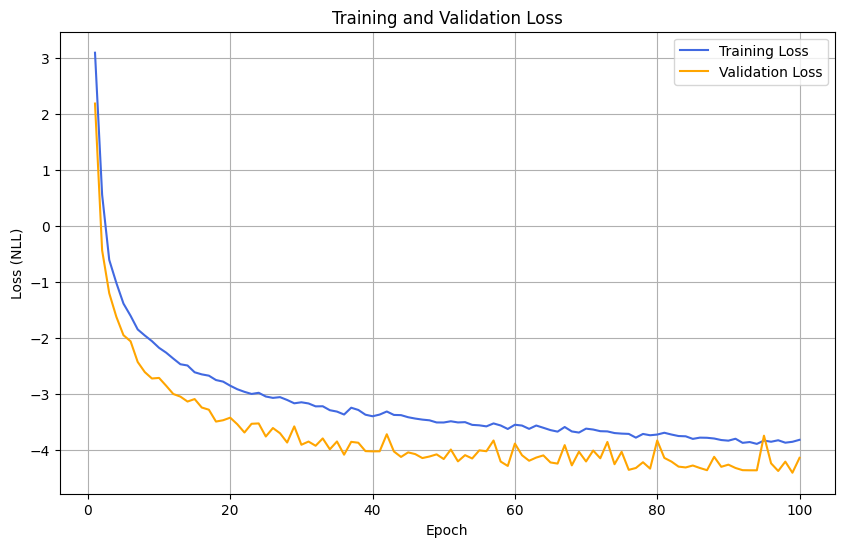

In [ ]:
plot_loss(train_losses_diag, val_losses_diag)

# **SCATTER PLOTS**

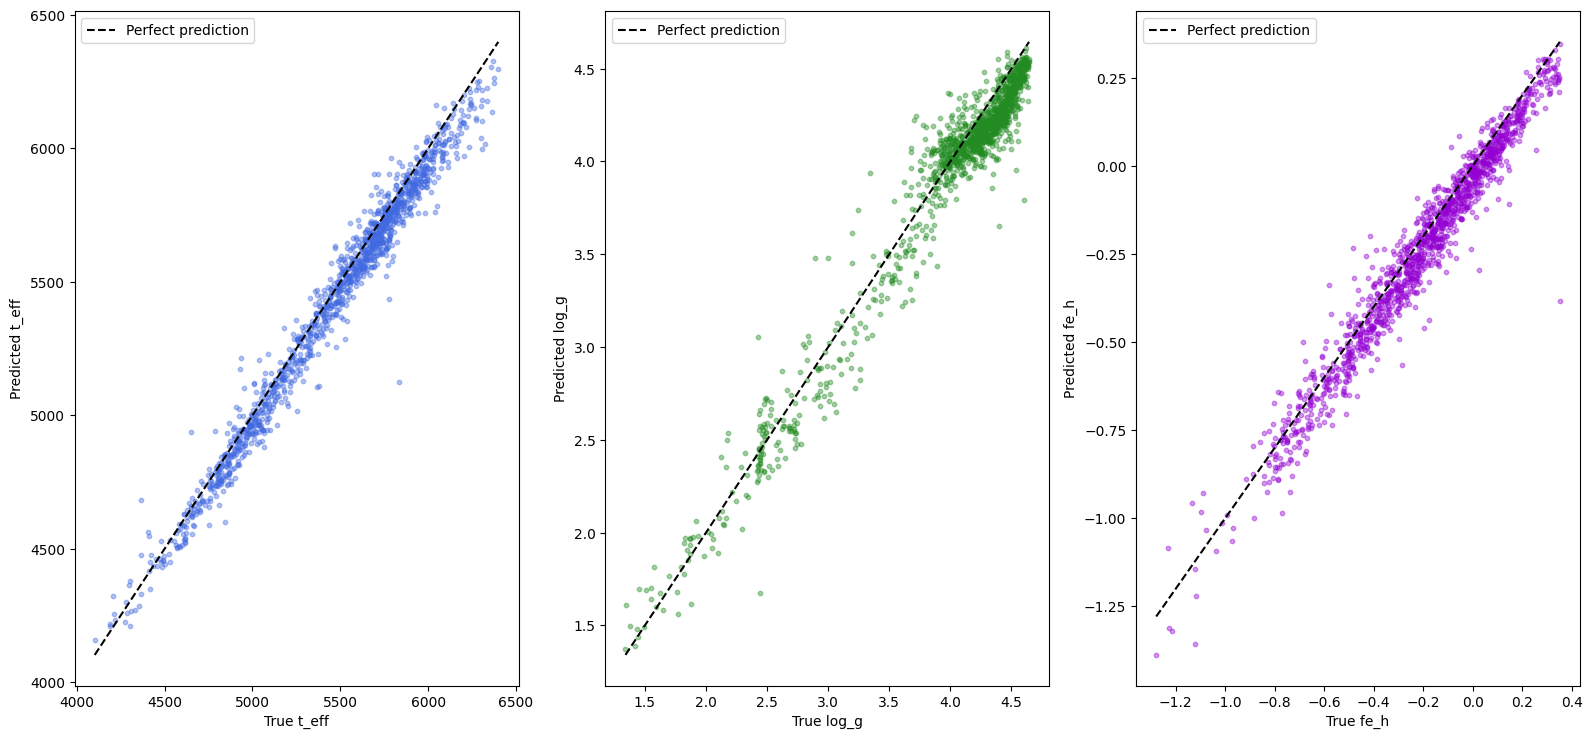

In [ ]:
plot_scatter(all_predictions_diag, all_true_labels_diag, labelNames)

# **PULL DISTRIBUTIONS**

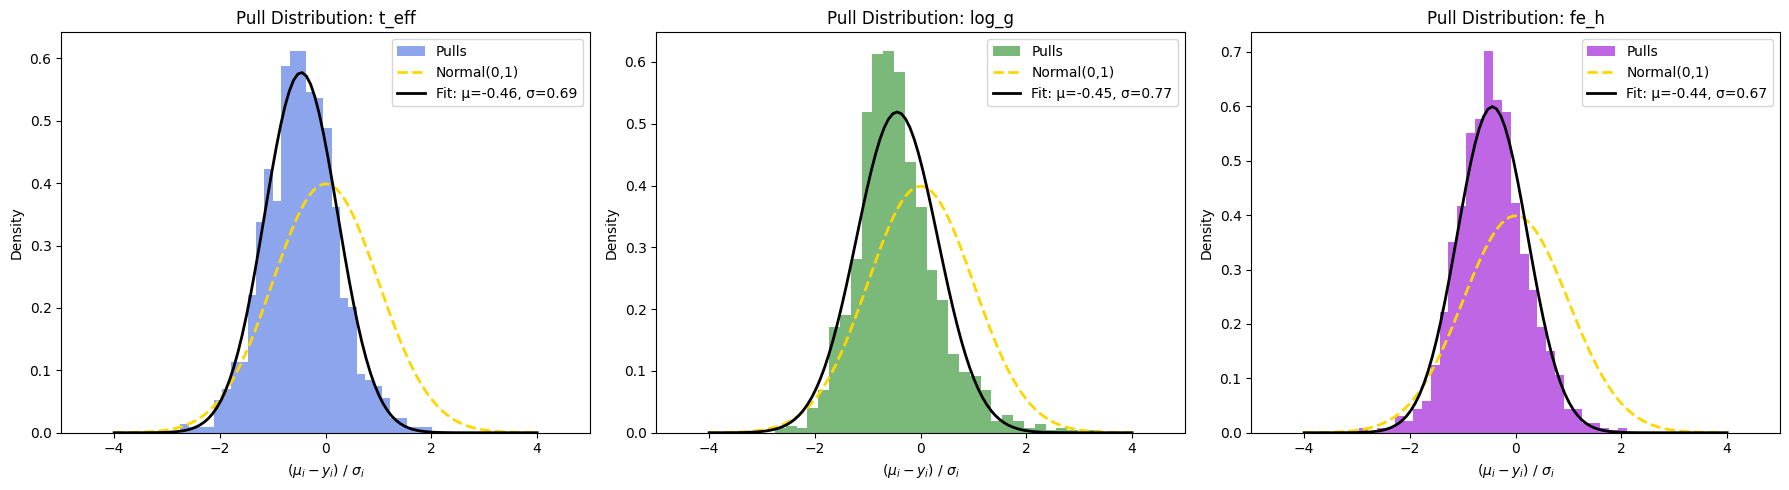

In [ ]:
plot_pulls(all_predictions_diag, all_true_labels_diag, all_uncertainties_diag, labelNames)

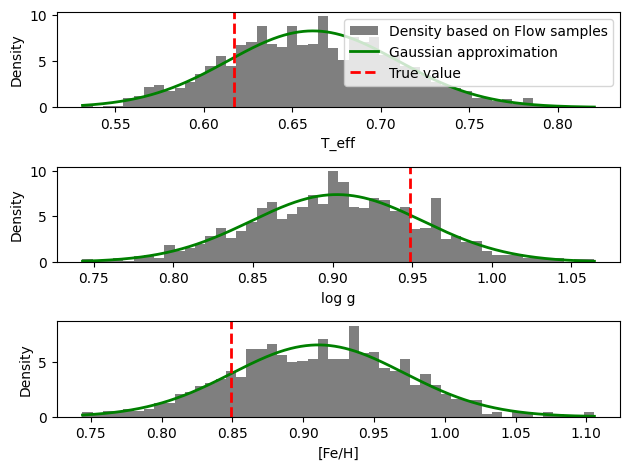

In [ ]:
model.visualize_pdf(input_data=first_spec_diag.to(device), filename=None, samplesize=1000, batch_index=0, truth=first_lab_diag[0].to(device))

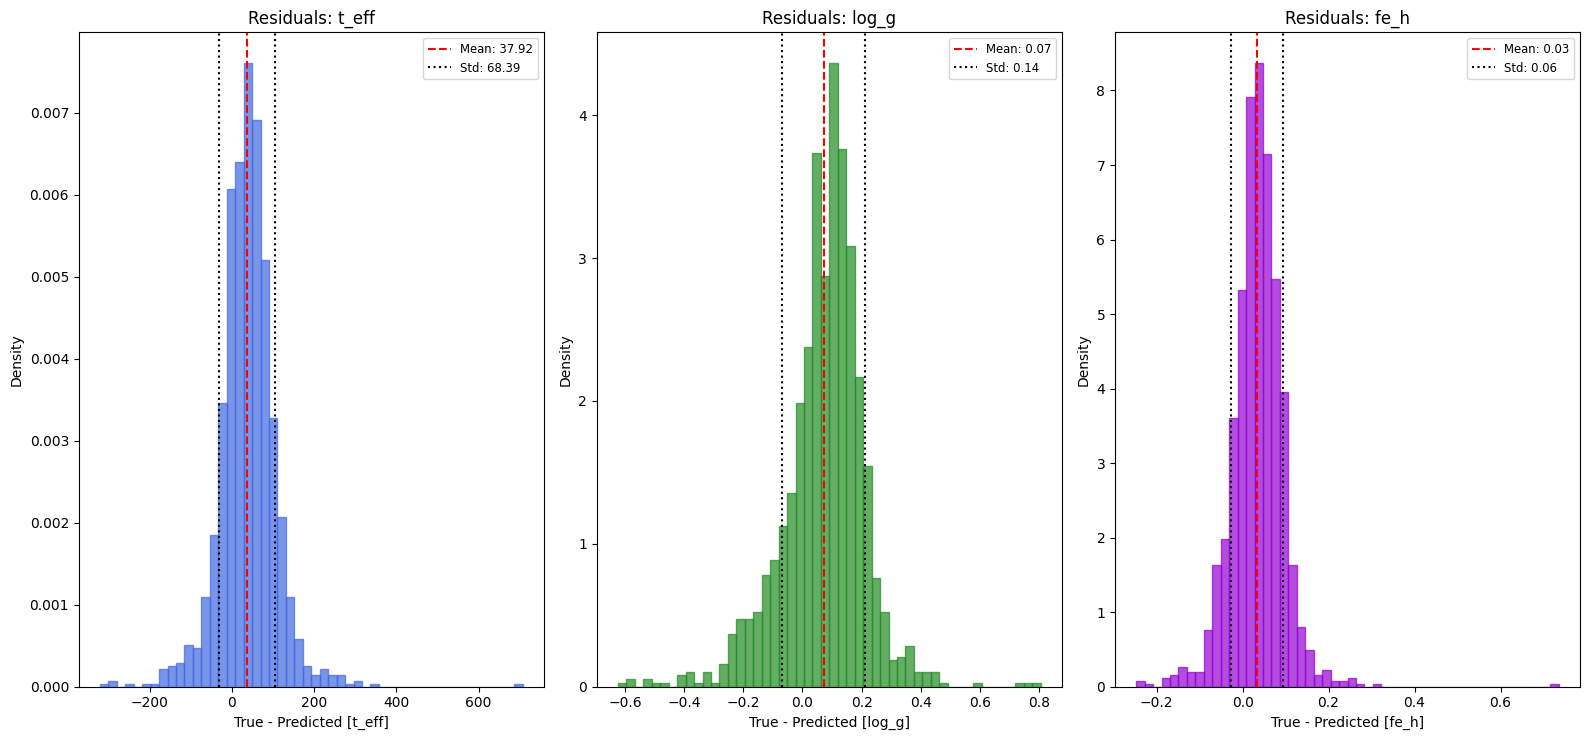

In [ ]:
plot_residuals(all_predictions_diag, all_true_labels_diag, labelNames)

# **UNCERTAINTY DISTRIBUTIONS**

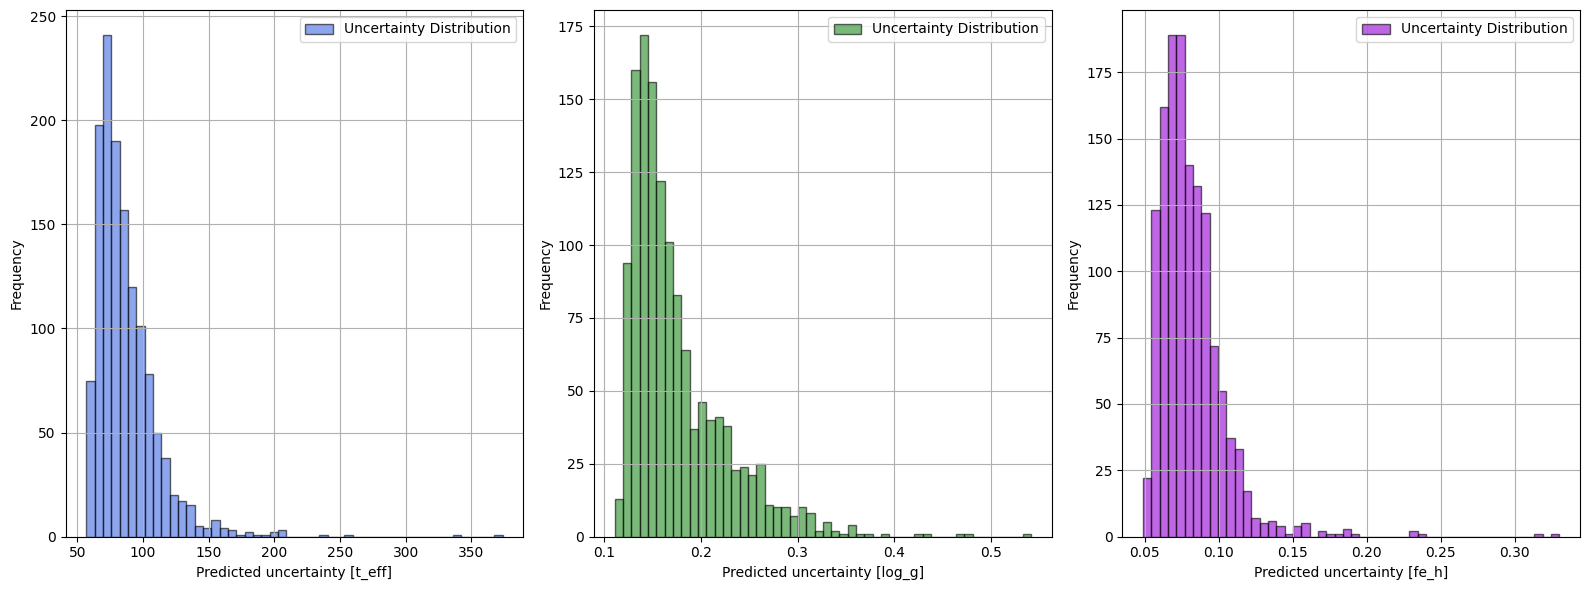

In [ ]:
uncertainty_distribution(all_uncertainties_diag, labelNames)

In [ ]:
model_choice = 'full_gaussian'

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH, return_SNR=False)

# Convert numpy arrays to PyTorch tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split the data into training, validation, and test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = NormFlow(encoder=TinyCNNEncoder, nf_type=model_choice).to(device)

if model_choice == "full_flow":
    model = model.to(torch.float64)


train_losses_full_g, val_losses_full_g, best_model_state_full_g = train_model_nf(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    patience=patience,
    device=device,
    model_name=model_choice
)

model.load_state_dict(best_model_state_full_g)

preds_norm_full_g, stds_norm_full_g, true_norm_full_g, first_spec_full_g, first_lab_full_g = evaluate_model(
    model,
    test_loader,
    device,
    samplesize=1000
)

all_predictions_full_g = denormalize(preds_norm_full_g, ranges)
all_true_labels_full_g = denormalize(true_norm_full_g, ranges)
all_uncertainties_full_g = denormalize_std(stds_norm_full_g, ranges)

Using device: cuda
The normalizing flow has  9  parameters...
Epoch [1/100], Step [40/49], Loss: 1.8816
Epoch [1/100], Train Loss: 2.6438, Val Loss: 1.7436, Time: 5.10 seconds
Epoch [2/100], Step [40/49], Loss: 0.1184
Epoch [2/100], Train Loss: 0.5231, Val Loss: -0.2203, Time: 2.49 seconds
Epoch [3/100], Step [40/49], Loss: -0.8485
Epoch [3/100], Train Loss: -0.6115, Val Loss: -1.1001, Time: 2.36 seconds
Epoch [4/100], Step [40/49], Loss: -1.1183
Epoch [4/100], Train Loss: -1.0695, Val Loss: -1.3632, Time: 2.37 seconds
Epoch [5/100], Step [40/49], Loss: -1.5908
Epoch [5/100], Train Loss: -1.2414, Val Loss: -1.3343, Time: 2.36 seconds
Epoch [6/100], Step [40/49], Loss: -1.6221
Epoch [6/100], Train Loss: -1.4410, Val Loss: -1.8403, Time: 2.47 seconds
Epoch [7/100], Step [40/49], Loss: -1.8377
Epoch [7/100], Train Loss: -1.6624, Val Loss: -2.0980, Time: 2.58 seconds
Epoch [8/100], Step [40/49], Loss: -1.8228
Epoch [8/100], Train Loss: -1.8033, Val Loss: -2.3355, Time: 2.44 seconds
Epoch [

# **LOSS PLOT**

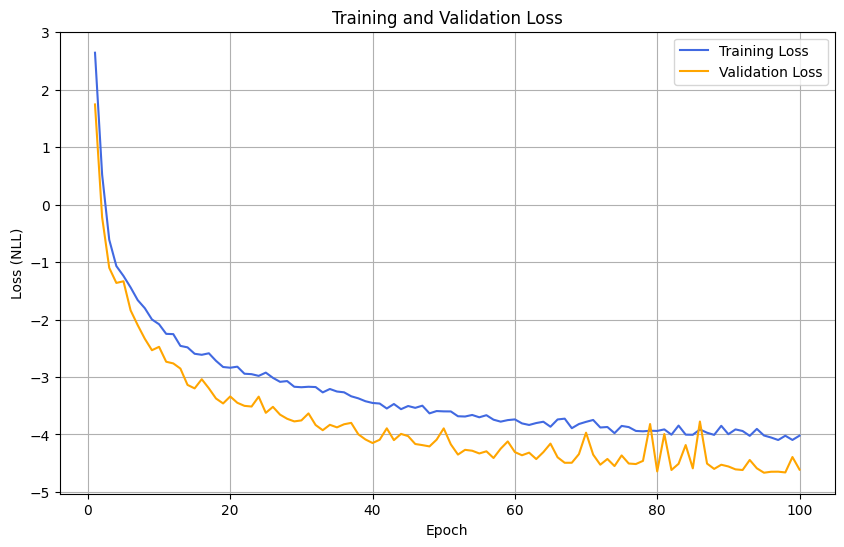

In [ ]:
plot_loss(train_losses_full_g, val_losses_full_g)

# **SCATTER PLOTS**

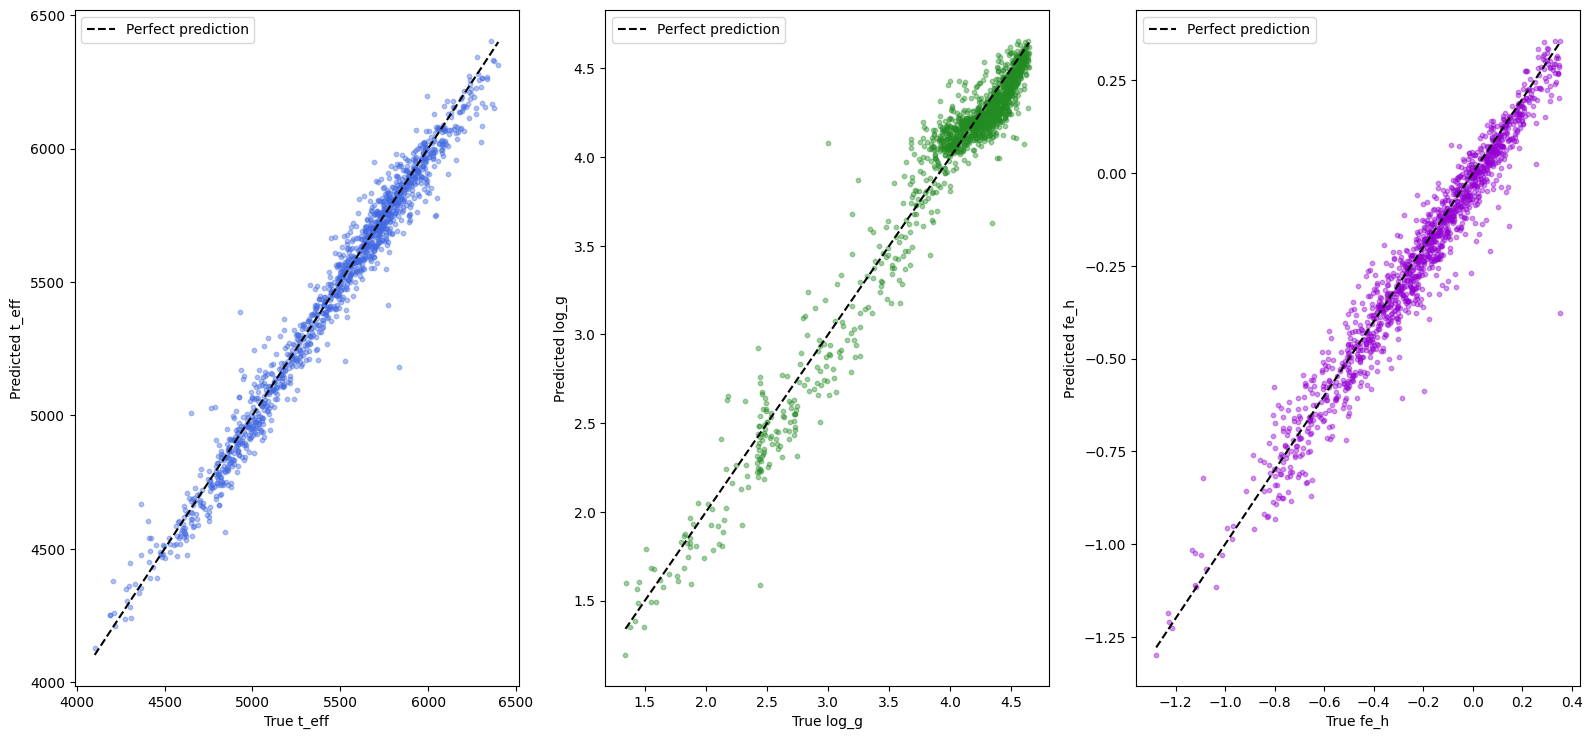

In [ ]:
plot_scatter(all_predictions_full_g, all_true_labels_full_g, labelNames)

# **PULL DISTRIBUTIONS**

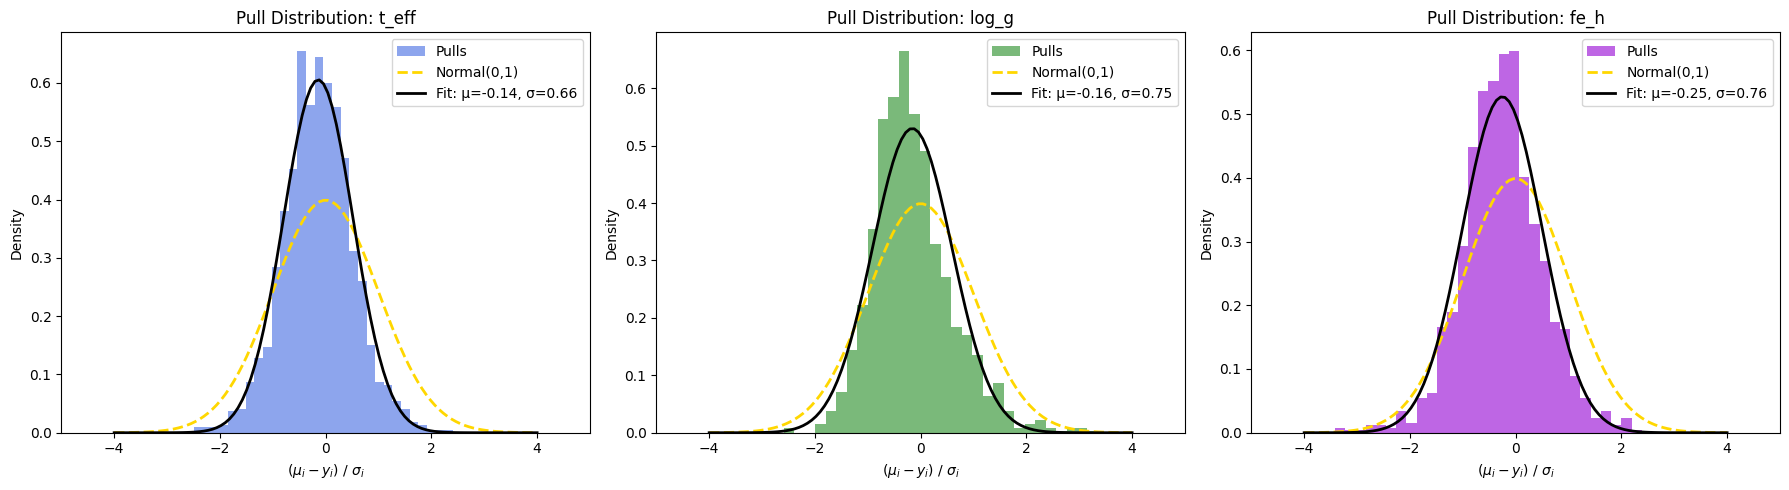

In [ ]:
plot_pulls(all_predictions_full_g, all_true_labels_full_g, all_uncertainties_full_g, labelNames)

# **RESIDUAL PLOT**

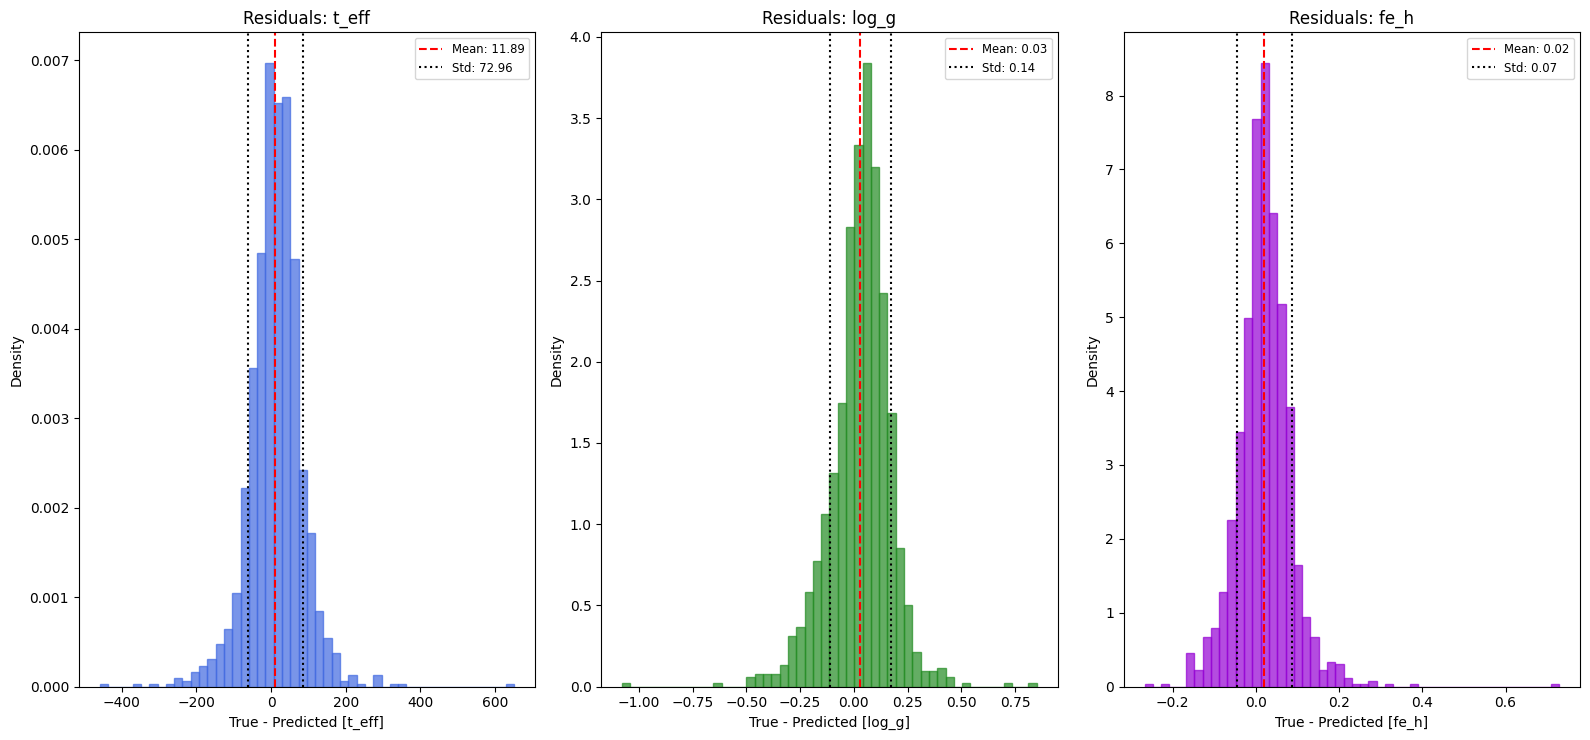

In [ ]:
plot_residuals(all_predictions_full_g, all_true_labels_full_g, labelNames)

# **VISUALIZE PDFs**

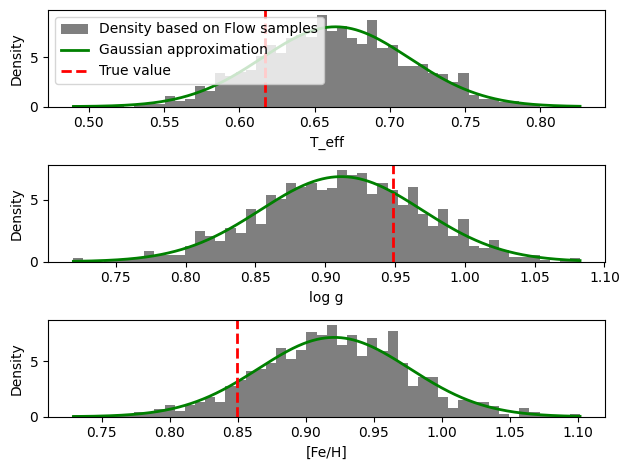

In [ ]:
model.visualize_pdf(
    input_data=first_spec_full_g.to(device), filename=None, samplesize=1000, batch_index=0, truth=first_lab_full_g[0].to(device)
)

# **UNCERTAINTY DISTRIBUTIONS**

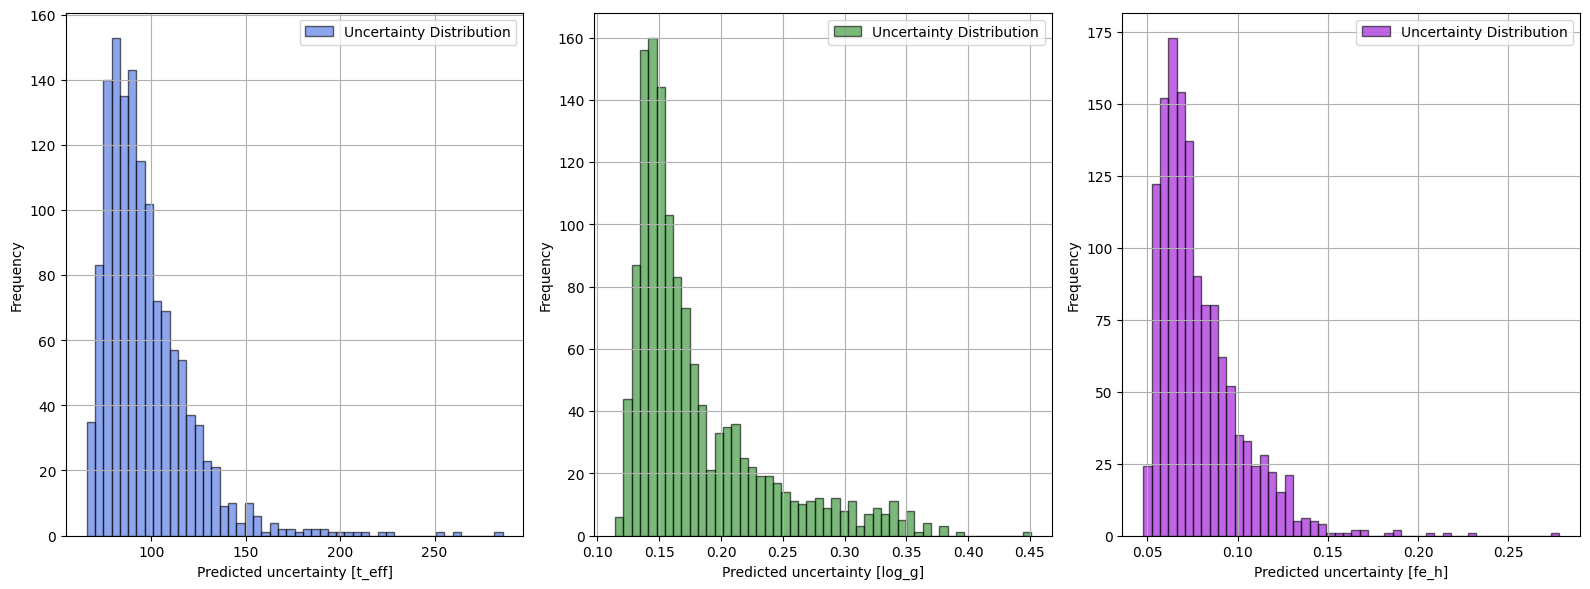

In [ ]:
uncertainty_distribution(all_uncertainties_full_g, labelNames)

# **FULL FLOW**

In [ ]:
model_choice = 'full_flow'

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH, return_SNR=False)

# Convert numpy arrays to PyTorch tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split the data into training, validation, and test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = NormFlow(encoder=TinyCNNEncoder, nf_type=model_choice).to(device)


train_losses_full_f, val_losses_full_f, best_model_state_full_f = train_model_nf(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    patience=patience,
    device=device,
    model_name=model_choice
)

model.load_state_dict(best_model_state_full_f)

preds_norm_full_f, stds_norm_full_f, true_norm_full_f, first_spec_full_f, first_lab_full_f = evaluate_model(
    model,
    test_loader,
    device,
    samplesize=1000
)

all_predictions_full_f = denormalize(preds_norm_full_f, ranges)
all_true_labels_full_f = denormalize(true_norm_full_f, ranges)
all_uncertainties_full_f = denormalize_std(stds_norm_full_f, ranges)


Using device: cuda
The normalizing flow has  306  parameters...
Epoch [1/100], Step [40/49], Loss: 6.2191
Epoch [1/100], Train Loss: 6.8502, Val Loss: 6.2830, Time: 3.64 seconds
Epoch [2/100], Step [40/49], Loss: 2.1156
Epoch [2/100], Train Loss: 3.6039, Val Loss: 1.2547, Time: 3.47 seconds
Epoch [3/100], Step [40/49], Loss: 0.4935
Epoch [3/100], Train Loss: 0.5644, Val Loss: 0.1552, Time: 3.69 seconds
Epoch [4/100], Step [40/49], Loss: 0.1180
Epoch [4/100], Train Loss: 0.1744, Val Loss: -0.0936, Time: 3.97 seconds
Epoch [5/100], Step [40/49], Loss: -0.1523
Epoch [5/100], Train Loss: -0.0791, Val Loss: -0.3275, Time: 3.54 seconds
Epoch [6/100], Step [40/49], Loss: -0.2214
Epoch [6/100], Train Loss: -0.2920, Val Loss: -0.6675, Time: 3.56 seconds
Epoch [7/100], Step [40/49], Loss: -0.7197
Epoch [7/100], Train Loss: -0.5424, Val Loss: -0.8073, Time: 3.84 seconds
Epoch [8/100], Step [40/49], Loss: -1.0744
Epoch [8/100], Train Loss: -0.8257, Val Loss: -1.1997, Time: 3.86 seconds
Epoch [9/10

# **LOSS PLOT**

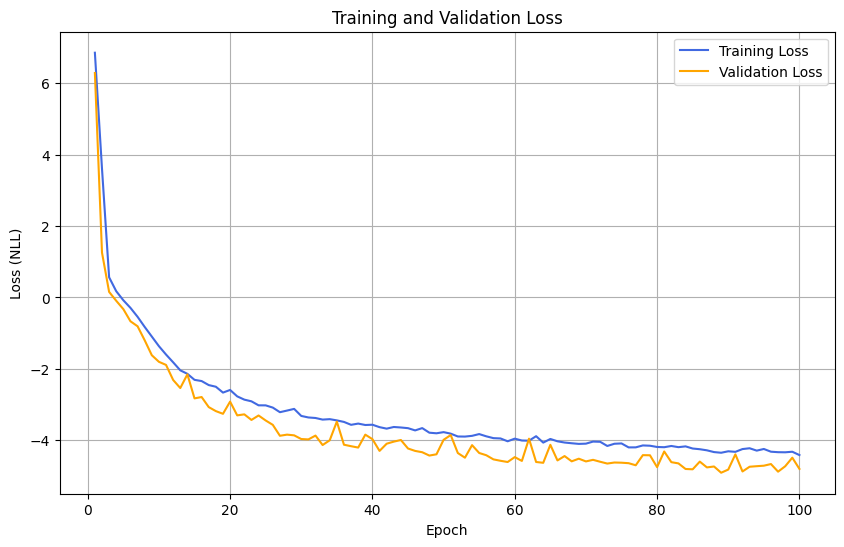

In [ ]:
plot_loss(train_losses_full_f, val_losses_full_f)

# **SCATTER PLOT**

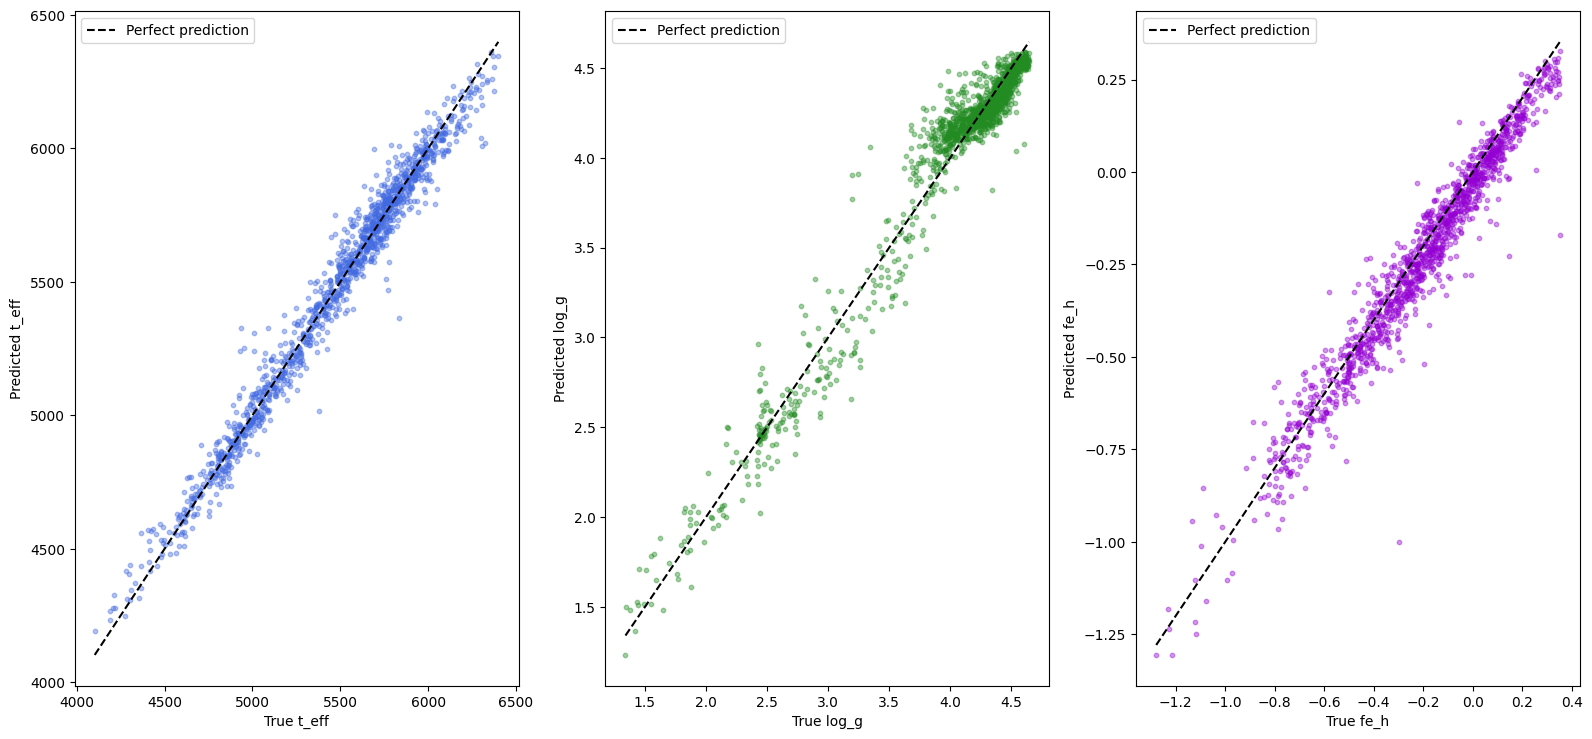

In [ ]:
plot_scatter(all_predictions_full_f, all_true_labels_full_f, labelNames)

# **PULL DISTRIBUTION**

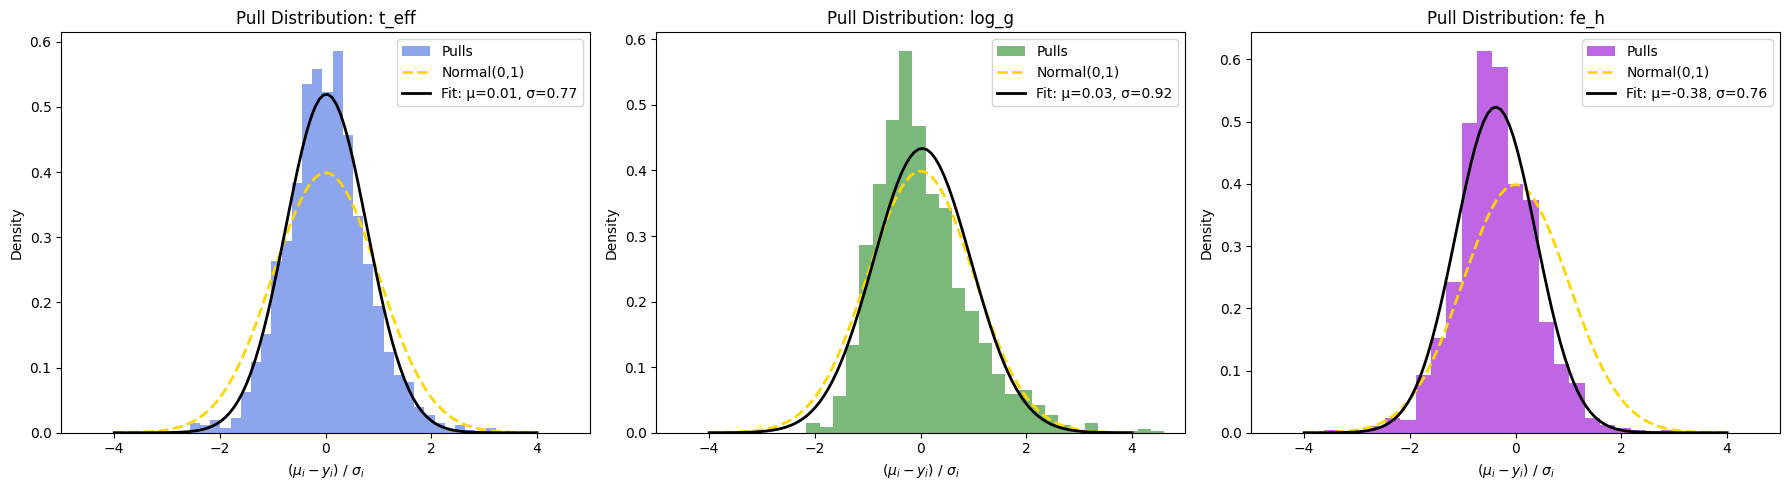

In [ ]:
plot_pulls(all_predictions_full_f, all_true_labels_full_f, all_uncertainties_full_f, labelNames)

# **RESIDUAL PLOT**

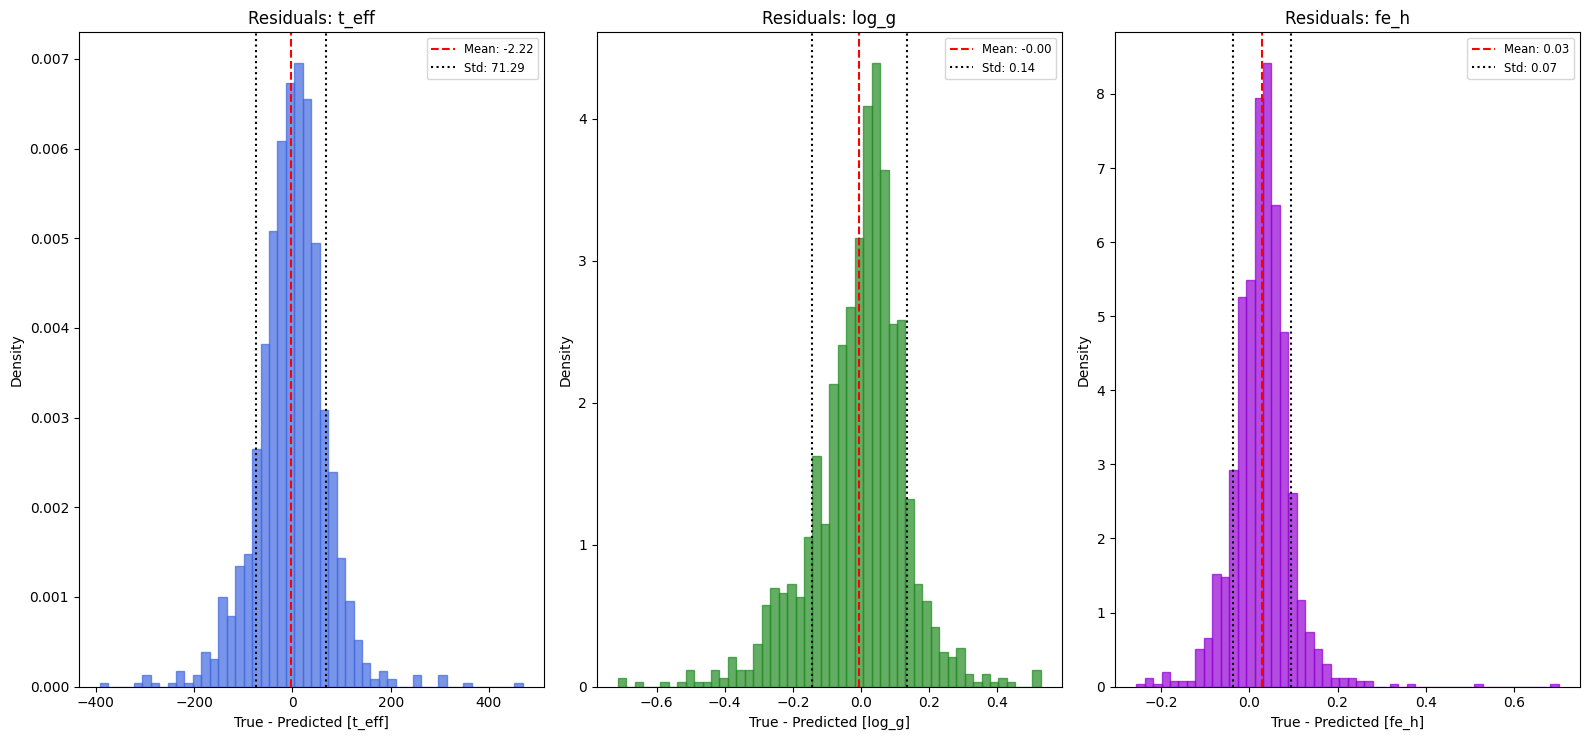

In [ ]:
plot_residuals(all_predictions_full_f, all_true_labels_full_f, labelNames)

# **VISUALIZE PDFs**

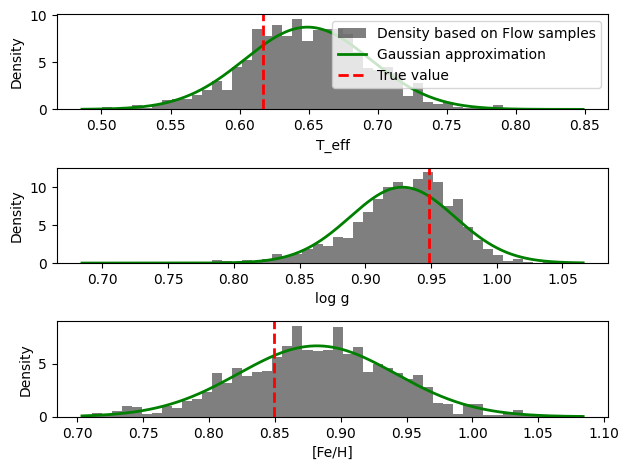

In [ ]:
model.visualize_pdf(input_data=first_spec_full_f.to(device), filename=None, samplesize=1000, batch_index=0, truth=first_lab_full_f[0].to(device))

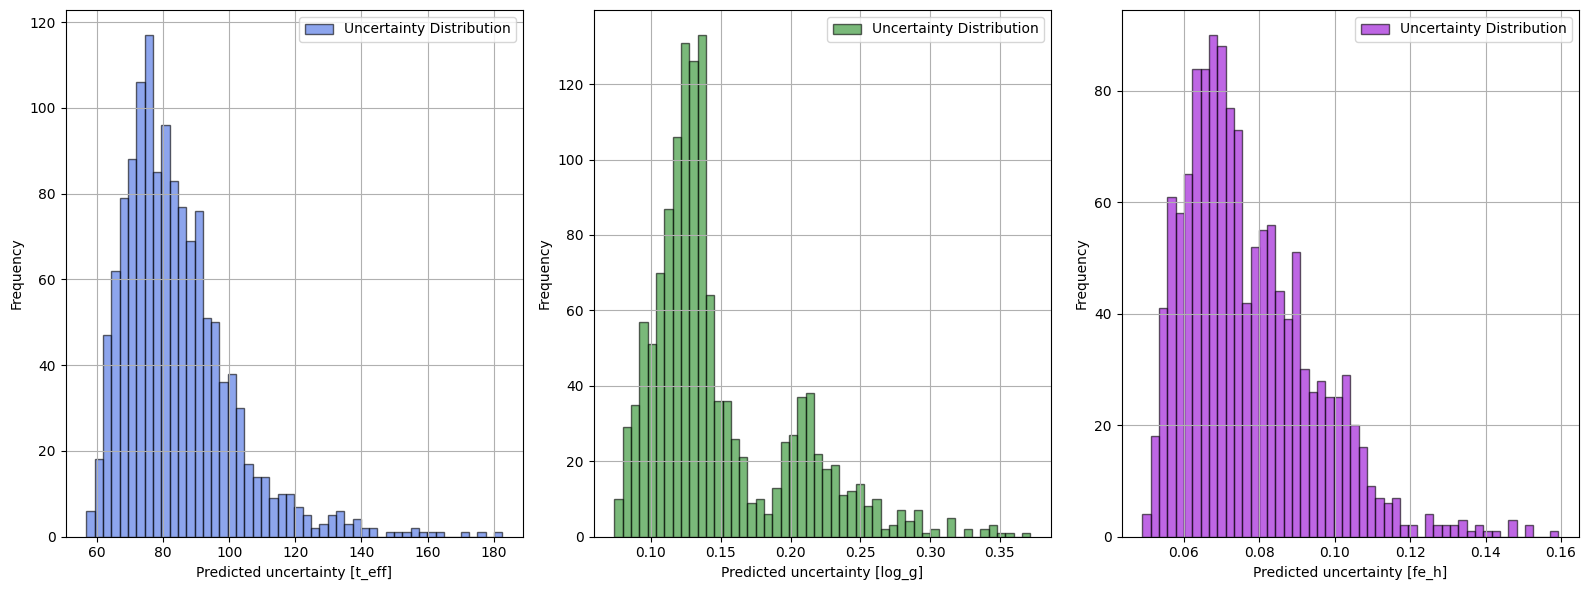

In [ ]:
uncertainty_distribution(all_uncertainties_full_f, labelNames)